# CLIP + FAISS Image Search

Text-to-image search over 500 CIFAR-10 images using OpenAI CLIP embeddings, FAISS nearest-neighbor lookup, and a Gradio UI.

## 1. Setup

In [1]:
!pip -q install transformers faiss-cpu gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.3 MB/s eta 0:00:00


In [2]:
import os
import pickle
import numpy as np
import torch
import faiss
import gradio as gr
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.datasets import CIFAR10
from transformers import CLIPProcessor, CLIPModel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


## 2. Data prep

Download CIFAR-10 test split and save the first 500 images as PNGs into `project_data/images/`.

In [4]:
os.makedirs("project_data/images", exist_ok=True)
print("Folder project_data/images is ready.")

Folder project_data/images is ready.


In [5]:
dataset = CIFAR10(root="project_data", train=False, download=True)
print("CIFAR-10 downloaded.")
print("Number of images in test split:", len(dataset))

100%|██████████| 170M/170M [00:01<00:00, 89.1MB/s]


CIFAR-10 downloaded.
Number of images in test split: 10000


In [6]:
max_images = 500

for i in range(max_images):
    img, label = dataset[i]
    img.save(f"project_data/images/img_{i:04d}.png")

print(f"Saved {max_images} images into project_data/images")

Saved 500 images into project_data/images


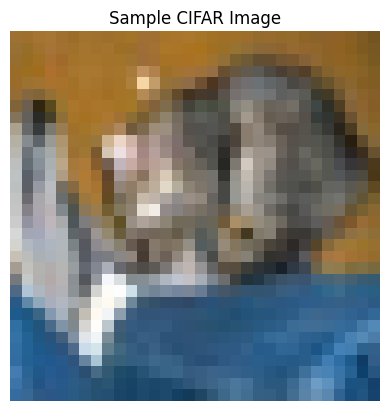

In [7]:
sample_path = "project_data/images/img_0000.png"
sample_img = Image.open(sample_path)

plt.imshow(sample_img)
plt.axis("off")
plt.title("Sample CIFAR Image")
plt.show()

## 3. Model load

Load pretrained `openai/clip-vit-base-patch32` via `CLIPProcessor` / `CLIPModel`.

In [8]:
model_name = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)

model = model.to(device)
model.eval()

print("CLIP model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model loaded


## 4. Image embeddings

Run CLIP's `get_image_features` on each PNG and L2-normalize so inner product equals cosine similarity.

In [9]:
image_folder = "project_data/images"

image_paths = []
for file in os.listdir(image_folder):
    if file.endswith(".png"):
        image_paths.append(os.path.join(image_folder, file))

image_paths = sorted(image_paths)
print("Total images:", len(image_paths))

Total images: 500


In [10]:
def get_image_embedding(img_path):
    img = Image.open(img_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.vision_model(**inputs)
        features = model.visual_projection(outputs.pooler_output)

    features = features / torch.norm(features, dim=-1, keepdim=True)
    return features.cpu().numpy().astype("float32")

## 5. Persistence

Cache `image_embeddings.npy` and `image_paths.pkl` so later runs skip the 500-image encode pass, then build a FAISS `IndexFlatIP` on the normalized vectors and save it to `faiss_index.bin`.

In [11]:
embeddings_path = "project_data/image_embeddings.npy"
paths_path = "project_data/image_paths.pkl"
index_path = "project_data/faiss_index.bin"

if os.path.exists(embeddings_path) and os.path.exists(paths_path):
    image_embeddings = np.load(embeddings_path)
    with open(paths_path, "rb") as f:
        image_paths = pickle.load(f)
    print("Loaded cached embeddings:", image_embeddings.shape)
else:
    all_embeddings = []
    for i, path in enumerate(image_paths):
        emb = get_image_embedding(path)
        all_embeddings.append(emb[0])
        if (i + 1) % 50 == 0:
            print("Processed", i + 1, "images")

    image_embeddings = np.array(all_embeddings).astype("float32")

    np.save(embeddings_path, image_embeddings)
    with open(paths_path, "wb") as f:
        pickle.dump(image_paths, f)

    print("finished creating embeddings")
    print("Shape:", image_embeddings.shape)

Processed 50 images
Processed 100 images
Processed 150 images
Processed 200 images
Processed 250 images
Processed 300 images
Processed 350 images
Processed 400 images
Processed 450 images
Processed 500 images
finished creating embeddings
Shape: (500, 512)


In [12]:
if os.path.exists(index_path):
    index = faiss.read_index(index_path)
    print("Loaded FAISS index from disk. ntotal =", index.ntotal)
else:
    dim = image_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(image_embeddings)
    faiss.write_index(index, index_path)
    print("Built FAISS IndexFlatIP. ntotal =", index.ntotal)

Built FAISS IndexFlatIP. ntotal = 500


## 6. Text query

Mirror the image encoder with `model.get_text_features` and the same L2 normalization.

In [13]:
def get_text_embedding(text):
    inputs = processor(text=[text], return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
      outputs = model.text_model(**inputs)
      features = model.text_projection(outputs.pooler_output)

    features = features / torch.norm(features, dim=-1, keepdim=True)
    return features.cpu().numpy().astype("float32")

## 7. Search

Encode the query text, run FAISS `index.search`, return the top-k paths and scores.

In [14]:
def search(query, k=5):
    vec = get_text_embedding(query)
    scores, idxs = index.search(vec, k)
    paths = [image_paths[i] for i in idxs[0]]
    return paths, scores[0].tolist()

In [15]:
paths, scores = search("a red car", k=5)
for p, s in zip(paths, scores):
    print(f"{s:.4f}  {p}")

0.2797  project_data/images/img_0246.png
0.2709  project_data/images/img_0351.png
0.2676  project_data/images/img_0081.png
0.2632  project_data/images/img_0114.png
0.2586  project_data/images/img_0366.png


## 8. Gradio UI

Textbox for the query, slider for `k`, gallery of retrieved images with similarity scores.

In [16]:
def gradio_search(query, k):
    if not query or not query.strip():
        return []
    paths, scores = search(query, k=int(k))

    from PIL import Image
    return [(Image.open(p), f"score: {s:.4f}") for p, s in zip(paths, scores)]

demo = gr.Interface(
    fn=gradio_search,
    inputs=[
        gr.Textbox(label="Query", placeholder="e.g. 'a red car' or 'dog on grass'"),
        gr.Slider(minimum=1, maximum=20, step=1, value=5, label="k"),
    ],
    outputs=gr.Gallery(label="Results", columns=5, height="auto"),
    title="CLIP + FAISS Image Search",
    description="Text-to-image retrieval over 500 CIFAR-10 images. Enter a query and wait a moment while CLIP encodes and FAISS retrieves results.",
    examples=[
        ["a red car", 5],
        ["a dog", 5],
        ["an airplane", 5],
        ["a truck", 5]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bec361533e8d2c35e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
